In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask
from matplotlib.ticker import FormatStrFormatter
from tqdm import tqdm

from config import *

from dataset_cfd import *
from lr_scheduler import *
from train import *
from config import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr

import json
import os

In [2]:
transformer = Transformer(
                        d_model        = D_MODEL,
                        N              = N,
                        num_heads      = NUM_HEADS,
                        d_ff           = D_FF,
                        patch_dim      = PATCH_DIM)

In [3]:
load_checkpoint("checkpoint_with_P.pt", transformer)

499

In [4]:
params = sum(p.numel() for p in transformer.parameters())
print(f"Total parameters: {params:,}")

Total parameters: 35,437,760


In [5]:
def fourier_features(cords: torch.tensor, num_freq = 8):
    # [num_patches, 2] -> [num_patches, num_freq * 2]
    freqs = 2 ** torch.linspace(0, num_freq - 1, num_freq)                   # [num_freqs]
    angles = (cords.unsqueeze(-1) * freqs  * torch.pi)                       # [num_patches, 2, num_freq]
    encoded = torch.cat([torch.sin(angles), torch.cos(angles)], dim = -1)    # [num_patches, 2, num_freq * 2]
    return encoded.view(cords.shape[0], -1)                                  # [num_patches, 2 * num_freq * 2]


patches_per_side = GRID_SIZE // PATCH_SIZE
coords = []
for row in range(patches_per_side):
    for col in range(patches_per_side):
        coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
coords_tensor = torch.tensor(coords, dtype=torch.float32)


# coords_tensor = fourier_features(coords_tensor)
# coords_tensor.shape


In [6]:
with open("train_test_re.json", "r", encoding="utf-8") as file:
    train_test_re = json.load(file)

In [7]:
pre_train_re  = sorted([float(i.split('.csv')[0].split("Re_")[-1]) for i in os.listdir("Data_with_P")])
post_train_re = sorted(train_test_re['test_re'] + train_test_re['train_re'])
pre_train_re

[8.43,
 16.76,
 20.0,
 25.09,
 33.42,
 41.75,
 45.0,
 50.08,
 58.41,
 66.74,
 70.0,
 75.07,
 83.4,
 91.73,
 95.0,
 100.06,
 108.39,
 116.72,
 120.0,
 125.05,
 133.38,
 141.71,
 145.0,
 150.04,
 158.37,
 166.7,
 170.0,
 175.03,
 183.36,
 191.69,
 195.0,
 200.02,
 208.35,
 216.68,
 220.0,
 225.01,
 233.34,
 241.67,
 245.0,
 250.0,
 258.33,
 266.66,
 270.0,
 274.99,
 283.32,
 291.65,
 295.0,
 299.98,
 308.31,
 316.64,
 320.0,
 324.97,
 333.3,
 341.63,
 345.0,
 349.96,
 358.29,
 366.62,
 370.0,
 374.95,
 383.28,
 391.61,
 395.0,
 399.94,
 408.27,
 416.6,
 420.0,
 424.93,
 433.26,
 441.59,
 445.0,
 449.92,
 458.25,
 466.58,
 470.0,
 474.91,
 483.24,
 491.57,
 495.0,
 499.9,
 508.23,
 516.56,
 524.89,
 533.22,
 541.55,
 549.88,
 558.21,
 566.54,
 574.87,
 583.2,
 591.53,
 599.86,
 608.19,
 616.52,
 624.85,
 633.18,
 641.51,
 649.84,
 658.17,
 666.5,
 674.83,
 683.16,
 691.49,
 699.82,
 708.15,
 716.48,
 724.81,
 733.14,
 741.47,
 749.8,
 758.13,
 766.46,
 774.79,
 783.12,
 791.45,
 799.78,
 

In [10]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, C, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(C, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

def predict(re_value, model, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size, patch_size, patch_dim, fourier_dimension,
            device="cpu", plot: bool = True):
    '''
    magic
    '''

    # normalize using dataset stats
    re_norm = (re_value - re_mean) / re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

    patches_per_side = grid_size // patch_size
    coords = []
    for row in range(patches_per_side):
        for col in range(patches_per_side):
            coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
    
    coords_tensor = fourier_features(torch.tensor(coords, dtype=torch.float32), num_freq = FOURIER_FEATURES)

    # decode
    src_mask = make_src_mask(src, -1)
    pred_patches = greedy_decode(
        model         = model, 
        src           = src, 
        src_mask      = src_mask,
        max_len       = (grid_size // patch_size)**2,
        patch_dim     = patch_dim - fourier_dimension, 
        coords_tensor = coords_tensor,
        device        = device, 
        num_freq = 16
    )  # (1, num_patches, patch_dim)


    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0],
                                   grid_size // patch_size,
                                   patch_size,
                                   grid_size)


    u = unrolled[0].detach().cpu()
    v = unrolled[1].detach().cpu()
    P = unrolled[2].detach().cpu()

    # denormalize
    u = (u * u_std) + u_mean
    v = (v * v_std) + v_mean
    P = (P * P_std) + P_mean

    # numerical gradients
    u_np = u
    v_np = v
    du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
    dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

    divergence = du_dx + dv_dy

    mag = np.sqrt(u**2 + v**2)

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)


        fig, axes = plt.subplots(1, 5, figsize=(27, 5))

        # u
        c0 = axes[0].contourf(x_grid, y_grid, u, levels=50, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        # v
        c1 = axes[1].contourf(x_grid, y_grid, v, levels=50, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        # p
        c2 = axes[2].contourf(x_grid, y_grid, P, levels=50, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        # mag
        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=50, cmap="jet")
        fig.colorbar(c2, ax=axes[3])
        # axes[2].streamplot(x_grid, y_grid, u, v, color="white", density=1.2)
        axes[3].set_title("|U|")# + streamlines")


        c4 = axes[4].contourf(divergence, levels=50, cmap="RdBu")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, P, divergence, mag


100%|██████████| 64/64 [00:00<00:00, 69.44it/s]


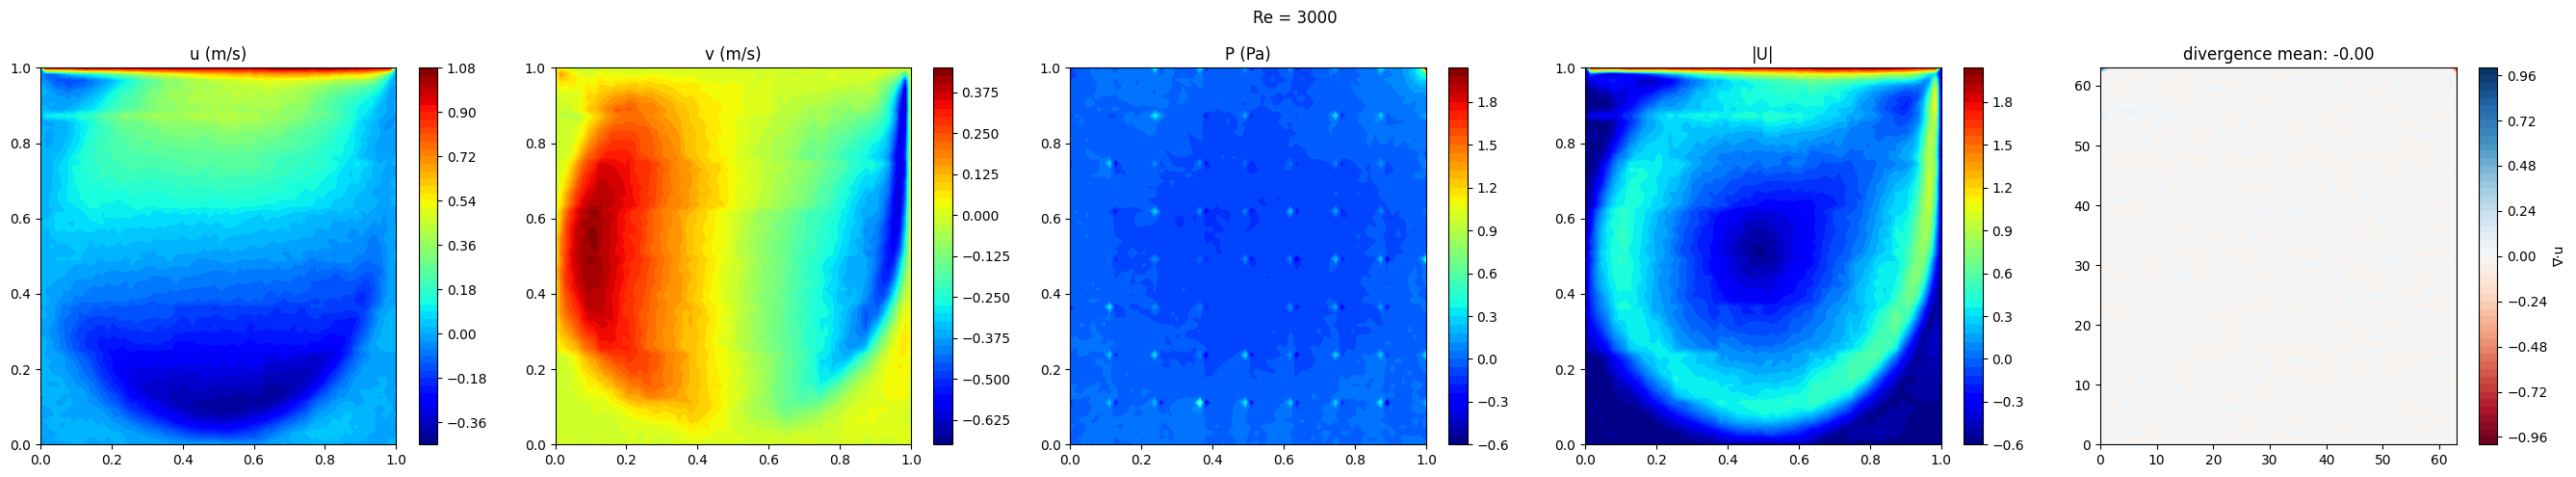

In [14]:
u, v, P, divergence, mag = predict(re_value = 3000, model = transformer, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = GRID_SIZE, patch_size = PATCH_SIZE, patch_dim = PATCH_DIM, fourier_dimension = FOURIER_DIMENSIONS,
                                   device = "cpu", plot = True
                                   )

100%|██████████| 64/64 [00:00<00:00, 65.74it/s]


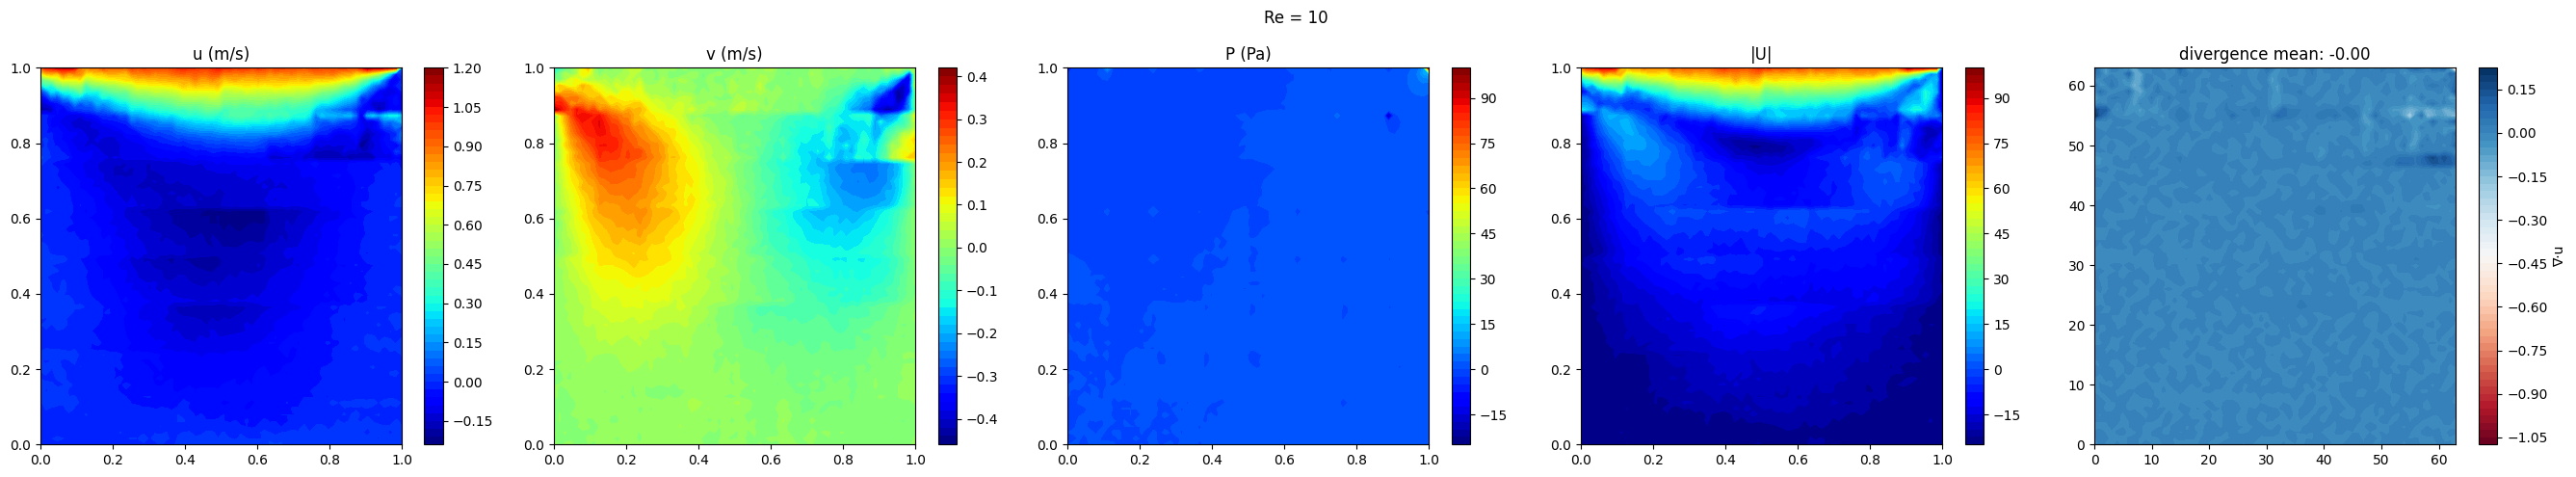

100%|██████████| 64/64 [00:00<00:00, 70.51it/s]


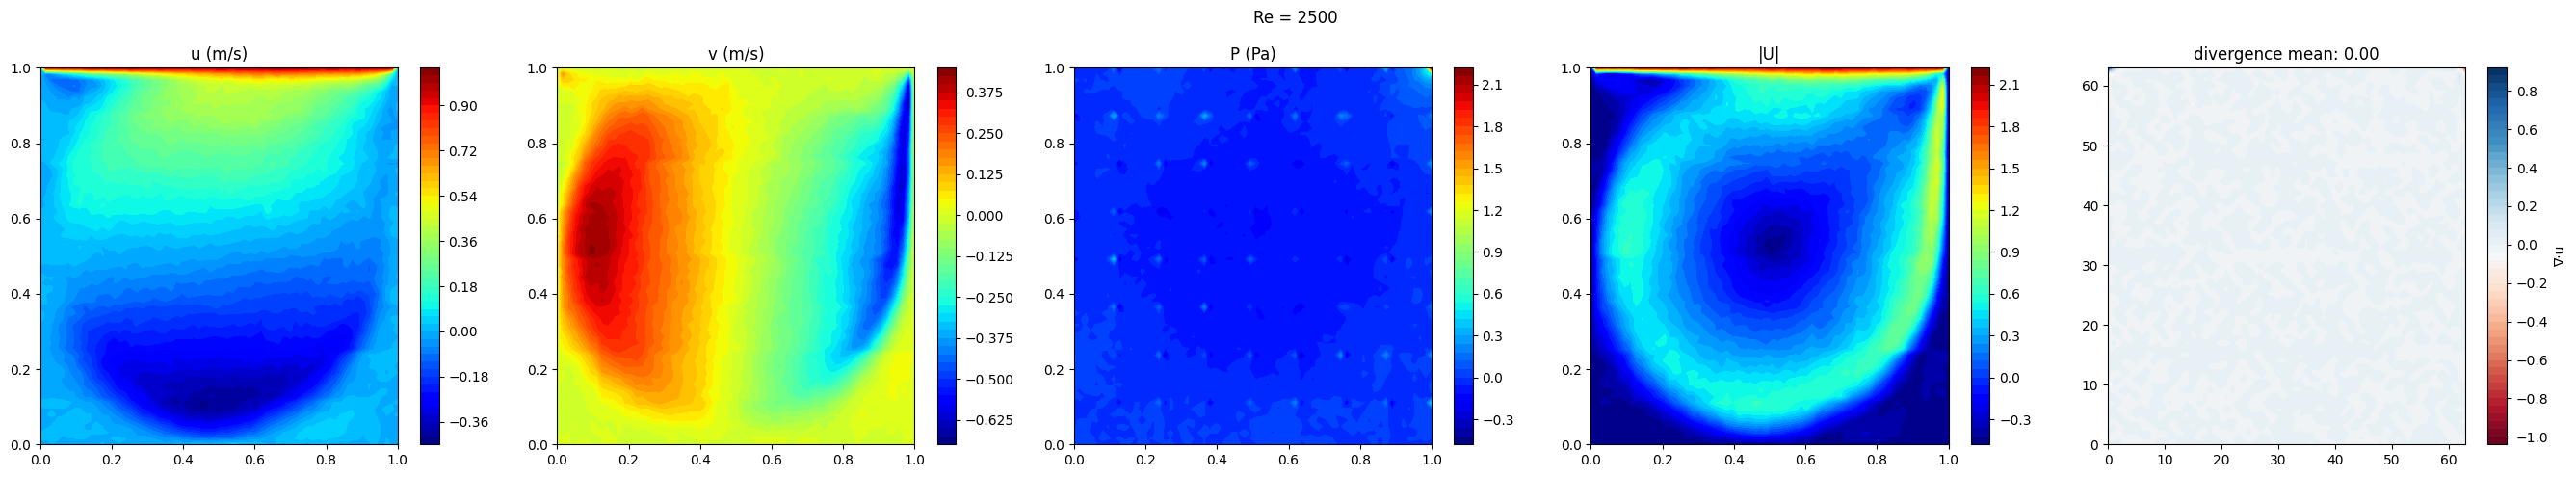

tensor(0.3299)

In [12]:
u_1, v_1, P_1, divergence_1, mag_1 = predict(re_value = 10, model = transformer, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = GRID_SIZE, patch_size = PATCH_SIZE, patch_dim = PATCH_DIM, fourier_dimension = FOURIER_DIMENSIONS,
                                   device = "cpu", plot = True
                                   )

u_2, v_2, P_2, divergence_2, mag_2 = predict(re_value = 2500, model = transformer, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = GRID_SIZE, patch_size = PATCH_SIZE, patch_dim = PATCH_DIM, fourier_dimension = FOURIER_DIMENSIONS,
                                   device = "cpu", plot = True
                                   )


torch.mean(((mag_1**2) + (mag_2**2))**0.5)

In [15]:
torch.abs(mag_1 - mag_2).mean()

tensor(0.1498)

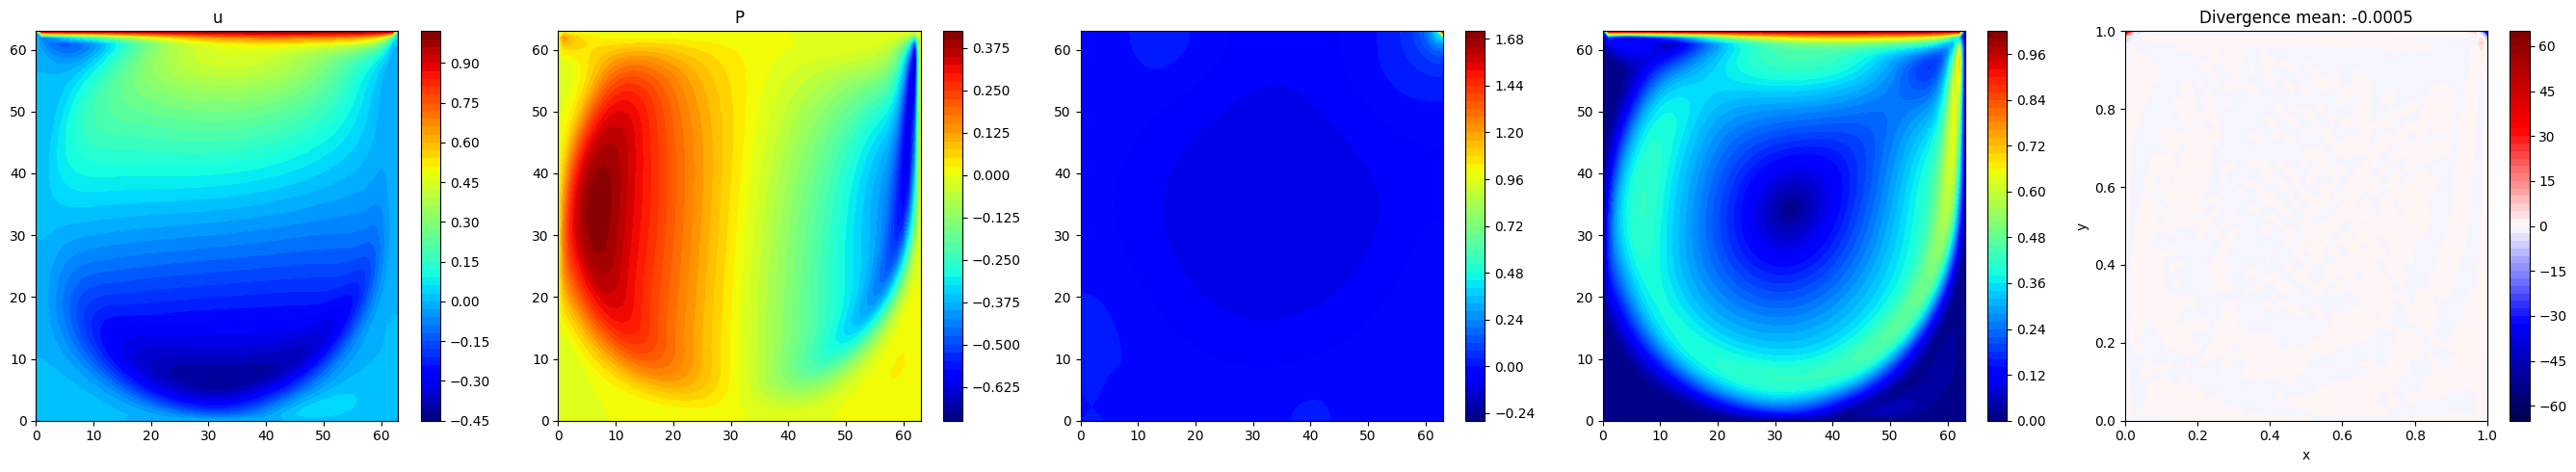

In [16]:
def ground_truth(re: float, plot: bool):

    assert f"Re_{re}.csv" in os.listdir("Data_with_P"), "make sure re is in the csv folder"

    df = pd.read_csv(f"Data_with_P/Re_{re}.csv", index_col = 0)

    lin = np.linspace(0, 1, 64)

    x = df['x']
    y = df['y']
    u = df["u (m/s)"].values.astype(np.float32)
    v = df["v (m/s)"].values.astype(np.float32)
    P = df["p (Pa)"].values.astype(np.float32)

    points = np.stack([x, y], axis=1)  # (N, 2)
    # interpolate u and v onto regular grid

    grid_x, grid_y = np.meshgrid(lin, lin) # (grid_size, grid_size)


    u_grid = griddata(points, u, (grid_x, grid_y), method="linear", fill_value=0.0)
    v_grid = griddata(points, v, (grid_x, grid_y), method="linear", fill_value=0.0)
    P_grid = griddata(points, P, (grid_x, grid_y), method="linear", fill_value=0.0)

    dx = lin[1] - lin[0]
    dy = lin[1] - lin[0]

    # gradients
    du_dx = np.gradient(u_grid, dx, axis=1)
    dv_dy = np.gradient(v_grid, dy, axis=0)

    # divergence
    div = du_dx + dv_dy

    mag = np.sqrt(u_grid**2 + v_grid**2)
    
    if plot:
        fig, axes = plt.subplots(1, 5, figsize=(27, 5))

        # u
        u_c = axes[0].contourf(u_grid, levels=50, cmap="jet")
        plt.colorbar(u_c, ax=axes[0])
        axes[0].set_title("u")

        # v
        v_c = axes[1].contourf(v_grid, levels=50, cmap="jet")
        plt.colorbar(v_c, ax=axes[1])
        axes[1].set_title("u")

        # P
        p_c = axes[2].contourf(P_grid, levels=50, cmap="jet")
        plt.colorbar(p_c, ax=axes[2])
        axes[1].set_title("P")

        # mag
        mag_c = axes[3].contourf(mag, levels=50, cmap="jet")
        plt.colorbar(mag_c, ax=axes[3])

        # div
        div_c = axes[4].contourf(grid_x, grid_y, div, levels=50, cmap="seismic")
        plt.colorbar(div_c, ax=axes[4])
        axes[4].set_title(f"Divergence mean: {div.mean():.4f}")
        axes[4].set_xlabel("x")
        axes[4].set_ylabel("y")

        plt.tight_layout()
        plt.show()
    
    return u_grid, v_grid, P_grid, div, mag

u_grid, v_grid, P_grid, div, mag = ground_truth(re = 2499.1, plot=True)

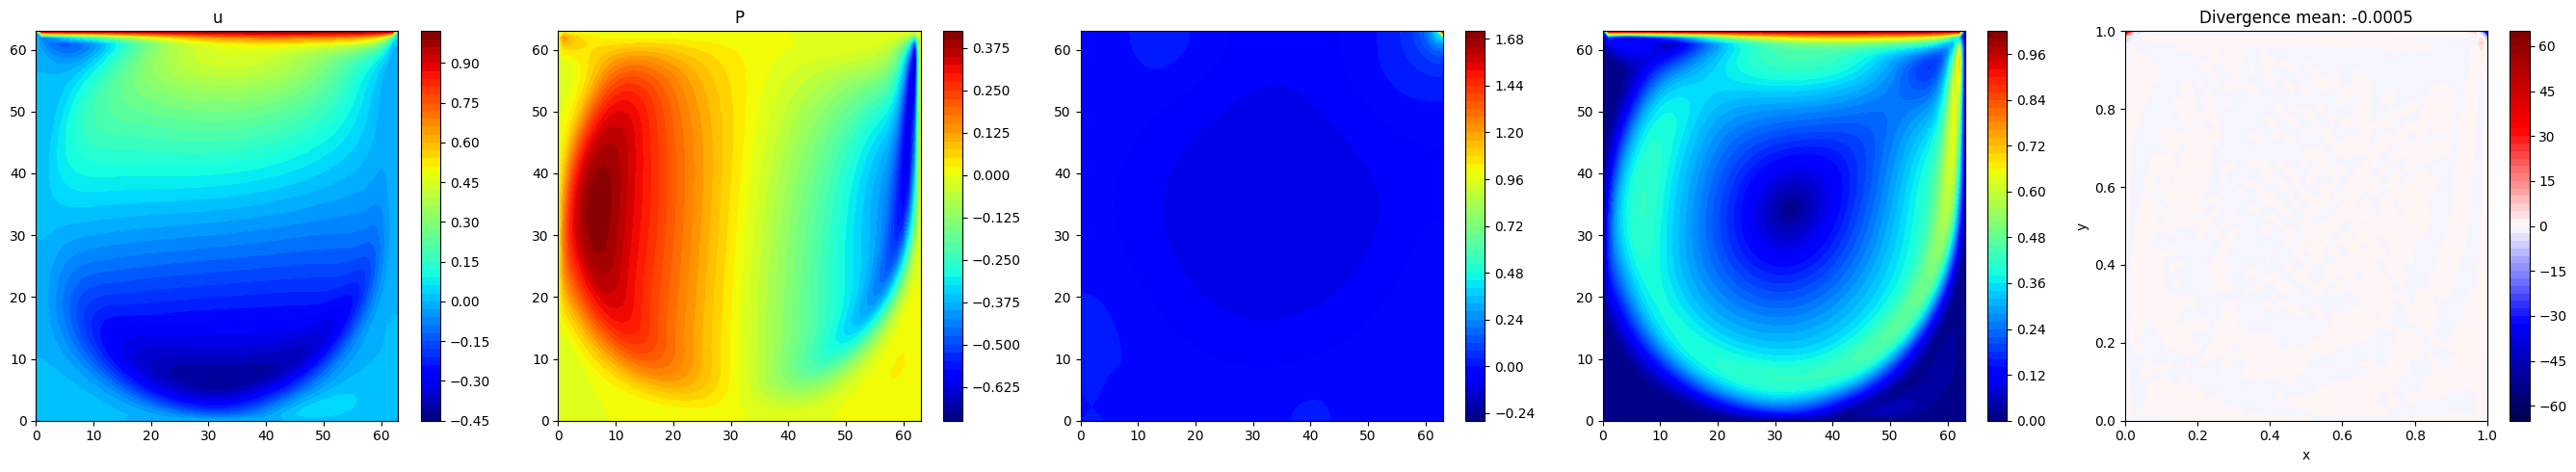

100%|██████████| 64/64 [00:01<00:00, 63.97it/s]


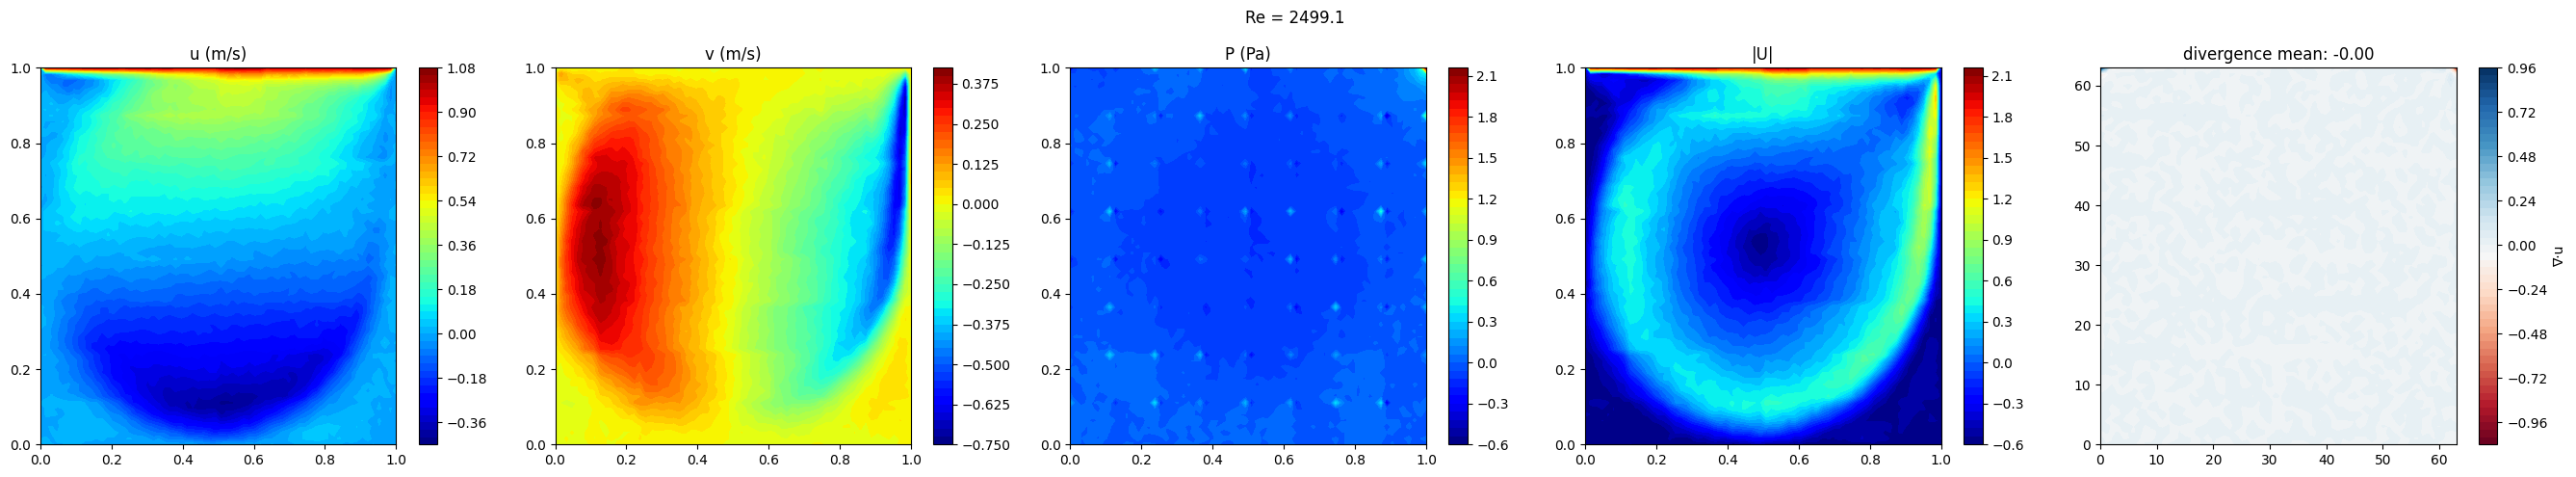

In [17]:
re = 2499.1
u_grid_actual, v_grid_actual, P_grid, div_actual, mag_actual = ground_truth(re = re, plot=True)

u_pred, v_pred, P_pred, div_pred, mag_pred = predict(re_value = re, model = transformer, 
                                                     re_mean = RE_MEAN, re_std = RE_STD, 
                                                     u_mean = U_MEAN,   u_std = U_STD, 
                                                     v_mean = V_MEAN,   v_std = V_STD, 
                                                     P_mean = P_MEAN,   P_std = P_STD,
                                                     grid_size = GRID_SIZE, patch_size = PATCH_SIZE, patch_dim = PATCH_DIM, fourier_dimension = FOURIER_DIMENSIONS,
                                                     device = "cpu", plot = True
                                                     )

In [22]:
errors = {}
frames = []

for re_idx in range(len(pre_train_re)):

    err = {}

    u_grid_actual, v_grid_actual, p_grid_actual, div_actual, mag_actual = ground_truth(
        re=pre_train_re[re_idx],
        plot=False
    )

    u_grid_pred, v_grid_pred, p_grid_pred, div_pred, mag_pred = predict(
        re_value=pre_train_re[re_idx],
        model=transformer,
        re_mean=RE_MEAN,
        re_std=RE_STD,
        u_mean=U_MEAN,
        u_std=U_STD,
        v_mean=V_MEAN,
        v_std=V_STD,
        P_mean=P_MEAN,
        P_std=P_STD,
        grid_size=GRID_SIZE,
        patch_size=PATCH_SIZE,
        patch_dim=PATCH_DIM,
        fourier_dimension=FOURIER_DIMENSIONS,
        device="cpu",
        plot=False
    )

    # absolute error maps for visualization
    u_difference   = torch.abs(torch.tensor(u_grid_actual) - u_grid_pred)
    v_difference   = torch.abs(torch.tensor(v_grid_actual) - v_grid_pred)
    p_difference   = torch.abs(torch.tensor(p_grid_actual) - p_grid_pred)
    mag_difference = torch.abs(torch.tensor(mag_actual) - mag_pred)
    div_difference = torch.abs(torch.tensor(div_actual) - div_pred)

    # RMSE metrics
    u_rmse   = torch.sqrt(((torch.tensor(u_grid_actual) - u_grid_pred) ** 2).mean())
    v_rmse   = torch.sqrt(((torch.tensor(v_grid_actual) - v_grid_pred) ** 2).mean())
    p_rmse   = torch.sqrt(((torch.tensor(p_grid_actual) - p_grid_pred) ** 2).mean())
    mag_rmse = torch.sqrt(((torch.tensor(mag_actual) - mag_pred) ** 2).mean())
    div_rmse = torch.sqrt(((torch.tensor(div_actual) - div_pred) ** 2).mean())

    err["u_error"]   = u_rmse.item()
    err["v_error"]   = v_rmse.item()
    err["p_error"]   = p_rmse.item()
    err["mag_error"] = mag_rmse.item()
    err["div_error"] = div_rmse.item()
    err["isTrain"]   = True if post_train_re[re_idx] in train_test_re['train_re'] else False

    errors[pre_train_re[re_idx]] = err

    fig, axes = plt.subplots(5, 3, figsize=(16, 24))

    lin = torch.linspace(0, 1, 64)

    ####################################################################
    # U
    ####################################################################
    c = axes[0, 0].contourf(lin, lin, u_grid_actual, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[0, 0], format=tkr.FormatStrFormatter('%.2f'))
    axes[0, 0].set_title("U Actual")

    c = axes[0, 1].contourf(lin, lin, u_grid_pred, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[0, 1], format=tkr.FormatStrFormatter('%.2f'))
    axes[0, 1].set_title("U Prediction")

    c = axes[0, 2].contourf(lin, lin, u_difference, levels=100, cmap="hot")
    plt.colorbar(c, ax=axes[0, 2], format=tkr.FormatStrFormatter('%.2f'))
    axes[0, 2].set_title(f"|U Error|\nRMSE={u_rmse:.4f} | Mean={u_difference.mean():.4e}")

    ####################################################################
    # V
    ####################################################################
    c = axes[1, 0].contourf(lin, lin, v_grid_actual, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[1, 0], format=tkr.FormatStrFormatter('%.2f'))
    axes[1, 0].set_title("V Actual")

    c = axes[1, 1].contourf(lin, lin, v_grid_pred, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[1, 1], format=tkr.FormatStrFormatter('%.2f'))
    axes[1, 1].set_title("V Prediction")

    c = axes[1, 2].contourf(lin, lin, v_difference, levels=100, cmap="hot")
    plt.colorbar(c, ax=axes[1, 2], format=tkr.FormatStrFormatter('%.2f'))
    axes[1, 2].set_title(f"|V Error|\nRMSE={v_rmse:.4f} | Mean={v_difference.mean():.4e}")

    ####################################################################
    # Pressure
    ####################################################################
    c = axes[2, 0].contourf(lin, lin, p_grid_actual, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[2, 0], format=tkr.FormatStrFormatter('%.2f'))
    axes[2, 0].set_title("Pressure Actual")

    c = axes[2, 1].contourf(lin, lin, p_grid_pred, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[2, 1], format=tkr.FormatStrFormatter('%.2f'))
    axes[2, 1].set_title("Pressure Prediction")

    c = axes[2, 2].contourf(lin, lin, p_difference, levels=100, cmap="hot")
    plt.colorbar(c, ax=axes[2, 2], format=tkr.FormatStrFormatter('%.2f'))
    axes[2, 2].set_title(f"|Pressure Error|\nRMSE={p_rmse:.4f} | Mean={p_difference.mean():.4e}")

    ####################################################################
    # Magnitude
    ####################################################################
    c = axes[3, 0].contourf(lin, lin, mag_actual, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[3, 0], format=tkr.FormatStrFormatter('%.2f'))
    axes[3, 0].set_title("Magnitude Actual")

    c = axes[3, 1].contourf(lin, lin, mag_pred, levels=100, cmap="jet")
    plt.colorbar(c, ax=axes[3, 1], format=tkr.FormatStrFormatter('%.2f'))
    axes[3, 1].set_title("Magnitude Prediction")

    c = axes[3, 2].contourf(lin, lin, mag_difference, levels=100, cmap="hot")
    plt.colorbar(c, ax=axes[3, 2], format=tkr.FormatStrFormatter('%.2f'))
    axes[3, 2].set_title(f"|Magnitude Error|\nRMSE={mag_rmse:.4f} | Mean={mag_difference.mean():.4e}")

    ####################################################################
    # Divergence
    ####################################################################
    c = axes[4, 0].contourf(lin, lin, div_actual, levels=100, cmap="BuPu")
    plt.colorbar(c, ax=axes[4, 0], format=tkr.FormatStrFormatter('%.2f'))
    axes[4, 0].set_title(f"Actual Divergence\nMean={torch.tensor(div_actual).mean():.4e}")

    c = axes[4, 1].contourf(lin, lin, div_pred, levels=100, cmap="BuPu")
    plt.colorbar(c, ax=axes[4, 1], format=tkr.FormatStrFormatter('%.2f'))
    axes[4, 1].set_title(f"Predicted Divergence\nMean={div_pred.mean():.4e}")

    c = axes[4, 2].contourf(lin, lin, div_difference, levels=100, cmap="hot")
    plt.colorbar(c, ax=axes[4, 2], format=tkr.FormatStrFormatter('%.2f'))
    axes[4, 2].set_title(f"|Divergence Error|\nRMSE={div_rmse:.4e} | Mean={div_difference.mean():.4e}")
    

    plt.suptitle(f"Re = {pre_train_re[re_idx]}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.renderer.buffer_rgba())
    frames.append(frame)
    plt.close(fig)

    # plt.show()

    # break


100%|██████████| 64/64 [00:00<00:00, 68.76it/s]


In [23]:
import imageio.v2 as imageio
imageio.mimsave("velocity_magnitude_comparison_with_P.mp4", frames, fps=10)

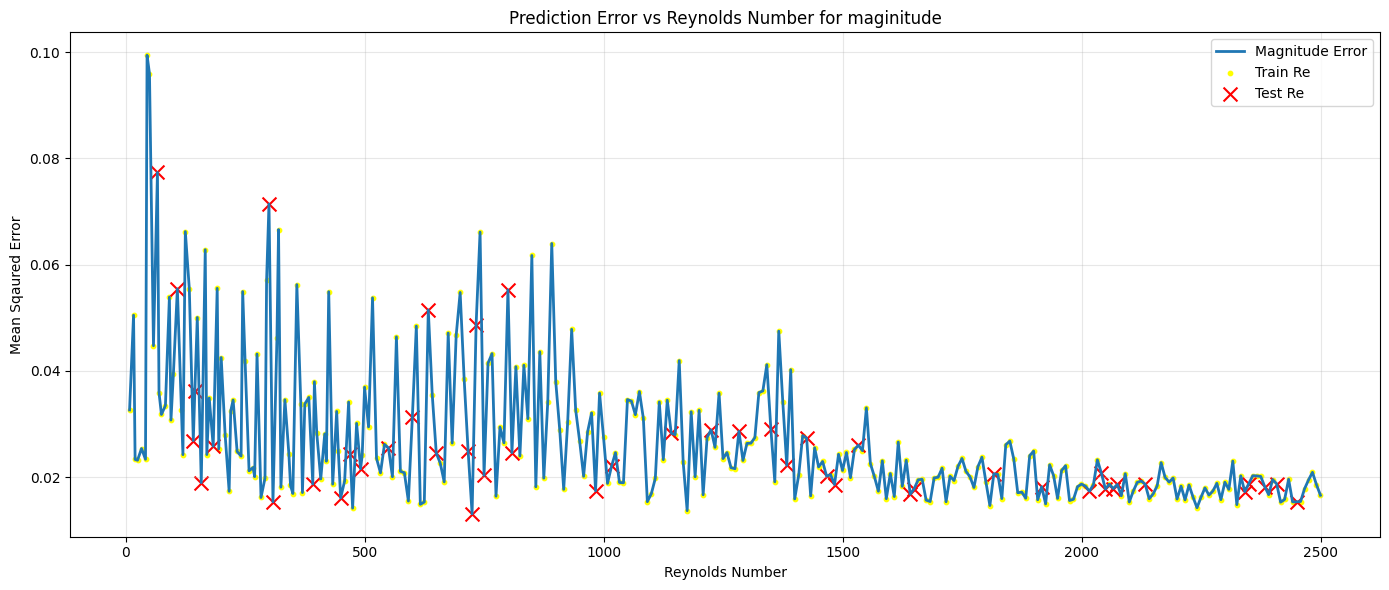

In [24]:
df = pd.DataFrame(errors).T.reset_index()
df = df.rename(columns={"index": "Re"})
df = df.sort_values("Re")

train_df = df[df["isTrain"]]
test_df  = df[df['isTrain'] == False]

plt.figure(figsize=(14, 6))

# Lines
# plt.plot(df["Re"], df["u_error"], label="U Error", linewidth=0.1)
# plt.plot(df["Re"], df["v_error"], label="V Error", linewidth=0.1)
plt.plot(df["Re"], df["mag_error"], label="Magnitude Error", linewidth=2)

# Train points
plt.scatter(
    train_df["Re"],
    train_df["mag_error"],
    marker="o",
    s=10,
    label="Train Re",
    color = "yellow"
)

# Test points
plt.scatter(
    test_df["Re"],
    test_df["mag_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

plt.xlabel("Reynolds Number")
plt.ylabel("Mean Sqaured Error")
plt.title("Prediction Error vs Reynolds Number for maginitude")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

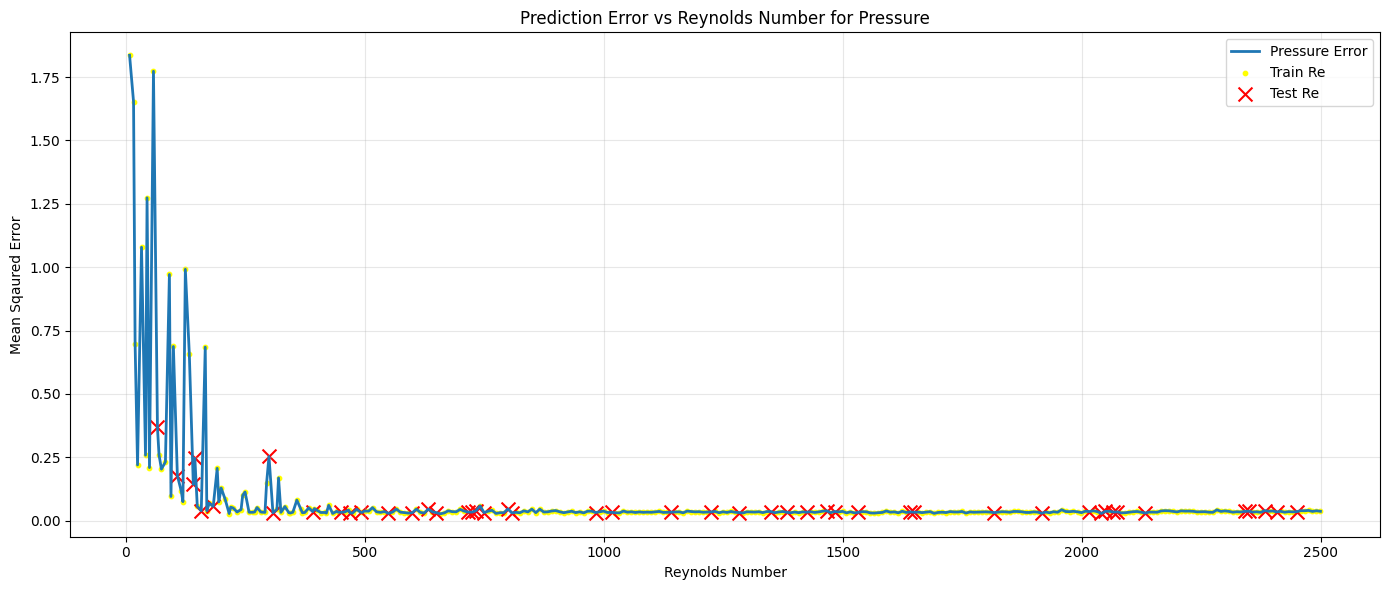

In [25]:
plt.figure(figsize=(14, 6))

# Lines
# plt.plot(df["Re"], df["u_error"], label="U Error", linewidth=0.1)
# plt.plot(df["Re"], df["v_error"], label="V Error", linewidth=0.1)
plt.plot(df["Re"], df["p_error"], label="Pressure Error", linewidth=2)

# Train points
plt.scatter(
    train_df["Re"],
    train_df["p_error"],
    marker="o",
    s=10,
    label="Train Re",
    color = "yellow"
)

# Test points
plt.scatter(
    test_df["Re"],
    test_df["p_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

plt.xlabel("Reynolds Number")
plt.ylabel("Mean Sqaured Error")
plt.title("Prediction Error vs Reynolds Number for Pressure")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

(array([120., 100., 101.]),
 array([1.0000e-01, 8.3310e+02, 1.6661e+03, 2.4991e+03]),
 <BarContainer object of 3 artists>)

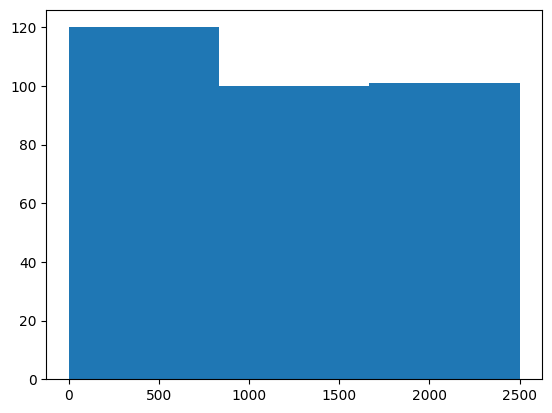

In [ ]:
start = 0.1
end = 2499.1
skip = 8.33

all = []

while start < end:
    all.append(round(start,2))
    start += skip


start = 20
end = 500
skip = 25


while start < end:
    ele = round(start,2)
    if ele not in all: all.append(ele)
    start += skip

all = sorted(all)

plt.hist(all,  bins = 3)

In [ ]:
for i in all:
    print(i, end = " ")

0.1 8.43 16.76 20 25.09 33.42 41.75 45 50.08 58.41 66.74 70 75.07 83.4 91.73 95 100.06 108.39 116.72 120 125.05 133.38 141.71 145 150.04 158.37 166.7 170 175.03 183.36 191.69 195 200.02 208.35 216.68 220 225.01 233.34 241.67 245 250.0 258.33 266.66 270 274.99 283.32 291.65 295 299.98 308.31 316.64 320 324.97 333.3 341.63 345 349.96 358.29 366.62 370 374.95 383.28 391.61 395 399.94 408.27 416.6 420 424.93 433.26 441.59 445 449.92 458.25 466.58 470 474.91 483.24 491.57 495 499.9 508.23 516.56 524.89 533.22 541.55 549.88 558.21 566.54 574.87 583.2 591.53 599.86 608.19 616.52 624.85 633.18 641.51 649.84 658.17 666.5 674.83 683.16 691.49 699.82 708.15 716.48 724.81 733.14 741.47 749.8 758.13 766.46 774.79 783.12 791.45 799.78 808.11 816.44 824.77 833.1 841.43 849.76 858.09 866.42 874.75 883.08 891.41 899.74 908.07 916.4 924.73 933.06 941.39 949.72 958.05 966.38 974.71 983.04 991.37 999.7 1008.03 1016.36 1024.69 1033.02 1041.35 1049.68 1058.01 1066.34 1074.67 1083.0 1091.33 1099.66 1107.99 1